In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [5]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Species']=le.fit_transform(df['Species'])
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,0
1,2,4.9,3.0,1.4,0.2,0
2,3,4.7,3.2,1.3,0.2,0
3,4,4.6,3.1,1.5,0.2,0
4,5,5.0,3.6,1.4,0.2,0


In [6]:
df['Species'].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

In [7]:
# y=f(x)
x=df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y=df['Species']
x.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y, test_size=0.2)

xtrain

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
79,5.7,2.6,3.5,1.0
81,5.5,2.4,3.7,1.0
61,5.9,3.0,4.2,1.5
90,5.5,2.6,4.4,1.2
51,6.4,3.2,4.5,1.5
...,...,...,...,...
32,5.2,4.1,1.5,0.1
116,6.5,3.0,5.5,1.8
117,7.7,3.8,6.7,2.2
136,6.3,3.4,5.6,2.4


In [9]:
from sklearn.tree import DecisionTreeClassifier

In [10]:
dt=DecisionTreeClassifier()
dt.fit(xtrain,ytrain)

DecisionTreeClassifier()

In [11]:
ypred=dt.predict(xtest)
ypred

array([2, 0, 2, 0, 0, 2, 2, 0, 0, 1, 2, 1, 2, 1, 2, 0, 0, 1, 0, 2, 2, 0,
       0, 2, 2, 0, 0, 2, 2, 1])

In [12]:
ytest

148    2
46     0
111    2
23     0
26     0
144    2
145    2
40     0
14     0
133    2
118    2
76     1
102    2
92     1
70     1
37     0
12     0
52     1
21     0
126    2
141    2
3      0
42     0
77     1
122    2
0      0
49     0
110    2
125    2
58     1
Name: Species, dtype: int32

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
a=accuracy_score(ypred,ytest)*100
a

90.0

In [14]:
cm=confusion_matrix(ypred,ytest)
cm

array([[12,  0,  0],
       [ 0,  4,  1],
       [ 0,  2, 11]], dtype=int64)

In [15]:
cr=classification_report(ypred,ytest)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.67      0.80      0.73         5
           2       0.92      0.85      0.88        13

    accuracy                           0.90        30
   macro avg       0.86      0.88      0.87        30
weighted avg       0.91      0.90      0.90        30



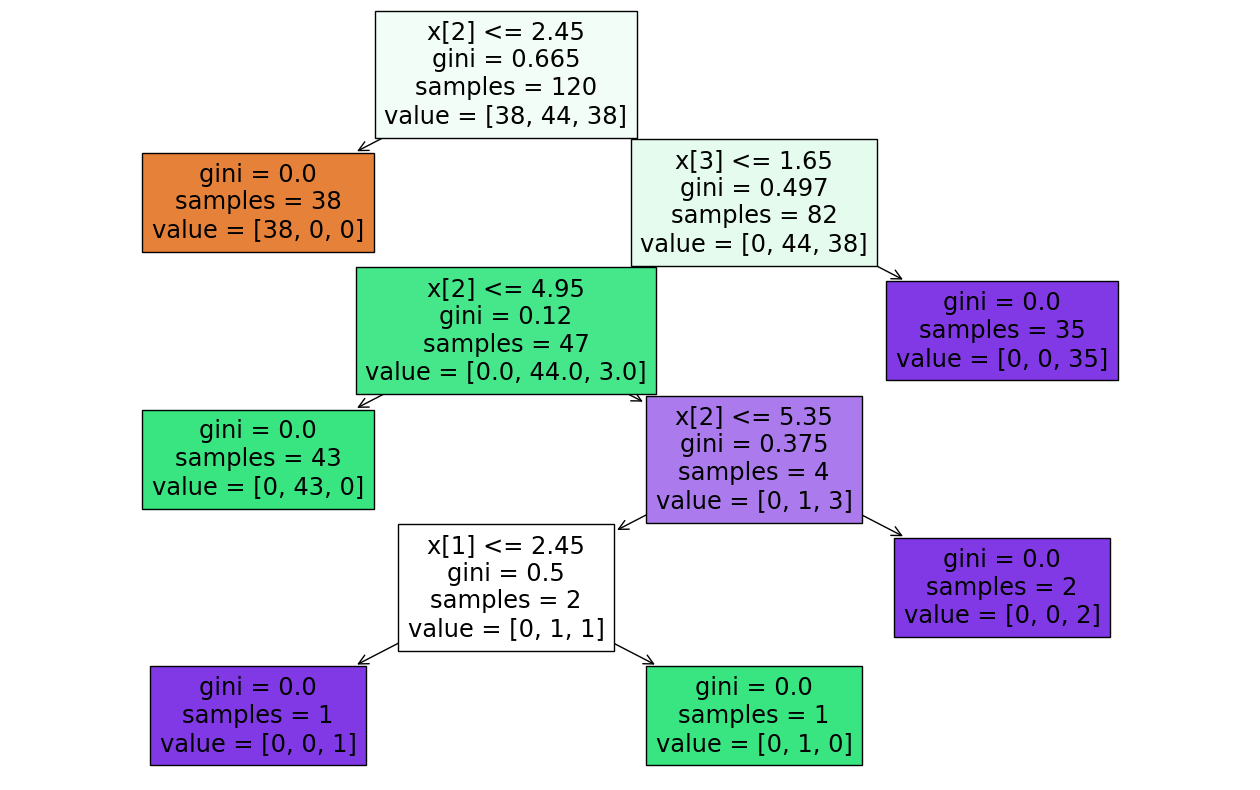

In [37]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(16,10))
tree.plot_tree(dt, filled=True)
plt.show()